<h2 style="color:blue">IE5005 Data Analytics For Industrial Engineers (Lecture 08)</h2>

<h2 style="color:orange">Clustering Methods</h2>

<h3 style="color:blue">K-means Clustering</h3>

In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline

Text(0, 0.5, 'X1')

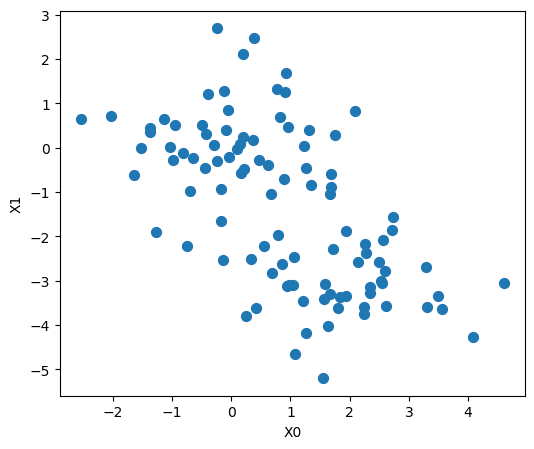

In [5]:
# For the demonstration purpose, I simulate a sample with two clusters
# The first cluster of observations have a relative shift in mean of second cluster
np.random.seed(111)
X = np.random.randn(100,2)
X[0:50, 0] = X[0:50, 0] + 2
X[0:50, 1] = X[0:50, 1] - 3

f, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:,0], X[:,1], s=50) 
ax.set_xlabel('X0')
ax.set_ylabel('X1')

In [6]:
# https://stackoverflow.com/questions/69596239/how-to-avoid-memory-leak-when-dealing-with-kmeans-for-example-in-this-code-i-am
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
# K-means with 2 clusters and a random initial state assignment of centroid specified as 111
kmeans_clustering = KMeans(n_clusters=2, n_init='auto', random_state=0).fit(X)
print(kmeans_clustering.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Text(0, 0.5, 'X1')

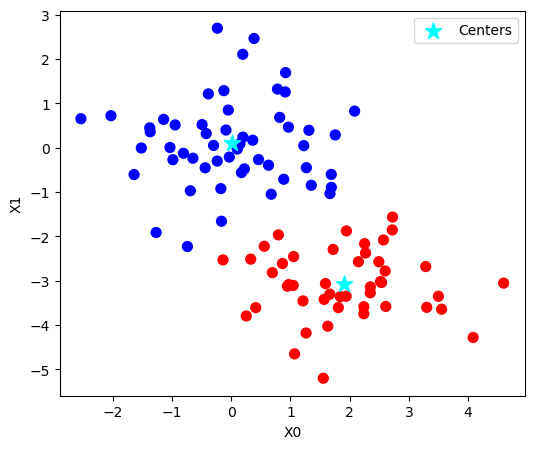

In [7]:
# Plot the identified clusters into different colors
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s = 50, c = kmeans_clustering.labels_, cmap = plt.cm.bwr) 
plt.scatter(kmeans_clustering.cluster_centers_[:, 0], 
            kmeans_clustering.cluster_centers_[:, 1], 
            marker = '*', 
            s = 150,
            color = 'cyan', 
            label = 'Centers')
plt.legend(loc = 'best')
plt.xlabel('X0')
plt.ylabel('X1')

Text(0, 0.5, 'X1')

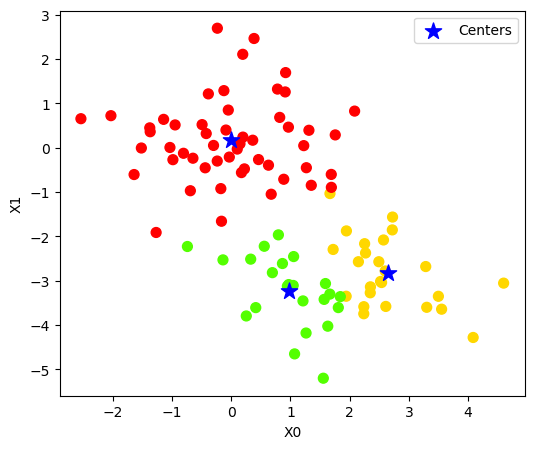

In [8]:
# In this example, we knew that there really were two clusters because we generated the data. However, for real data, in general we do not know the true number of clusters. We could instead have performed K-means clustering by trying out different values of K. 
# For instance, we try K=3

kmeans_3_clustering = KMeans(n_clusters = 3, n_init='auto',random_state = 111)
kmeans_3_clustering.fit(X)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50, c=kmeans_3_clustering.labels_, cmap=plt.cm.prism) 
plt.scatter(kmeans_3_clustering.cluster_centers_[:, 0], kmeans_3_clustering.cluster_centers_[:, 1], marker='*', s=150,
            color='blue', label='Centers')
plt.legend(loc='best')
plt.xlabel('X0')
plt.ylabel('X1')

In [9]:
# To run the Kmeans() function in python with multiple initial cluster assignments, we use the n_init argument (default: 10). If a value of n_init greater than one is used, then K-means clustering will be performed using multiple random assignments, and the Kmeans() function will report only the best results. Here we compare using n_init = 1:

km_out_single_run = KMeans(n_clusters = 3, n_init = 1, random_state = 123).fit(X)
km_out_single_run.inertia_

142.84748586615495

In [10]:
# Note that .inertia_ is the total within-cluster sum of squares, which we seek to minimize by performing K-means clustering.
km_out_single_run = KMeans(n_clusters = 3, n_init = 20, random_state = 123).fit(X)
km_out_single_run.inertia_

142.80122647546665

In [11]:
# It is generally recommended to always run K-means clustering with a large value of n_init, such as 20 or 50 to avoid getting stuck in an undesirable local optimum.

# When performing K-means clustering, in addition to using multiple initial cluster assignments, it is also important to set a random seed using the random_state parameter. This way, the initial cluster assignments can be replicated, and the K-means output will be fully reproducible.

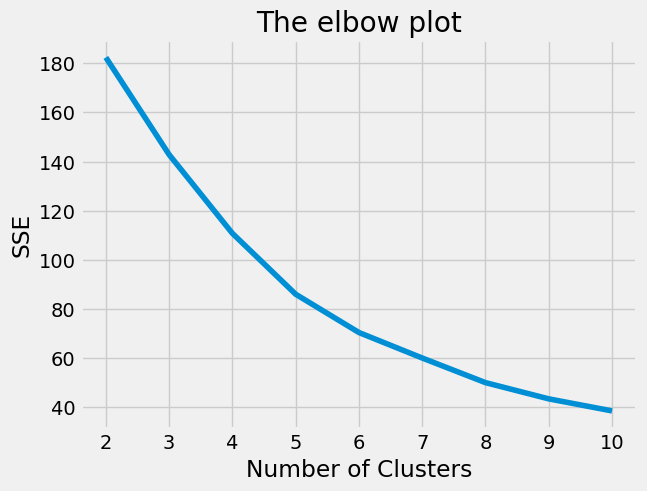

In [12]:
# 1. Elbow method
from sklearn.cluster import KMeans

kmeans_kwargs = {
   "init": "random",
   "n_init": 10,
   "max_iter": 300,
   "random_state": 111,
   }

# A list holds the SSE values for each k
sse = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

plt.style.use("fivethirtyeight")
plt.plot(range(2, 11), sse)
plt.title('The elbow plot')
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [13]:
!pip install kneed
# https://github.com/arvkevi/kneed
# Identify the optimal elbow point programatically
from kneed import KneeLocator
kl = KneeLocator(range(2, 11), sse, curve="convex", direction="decreasing")

kl.elbow


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


5

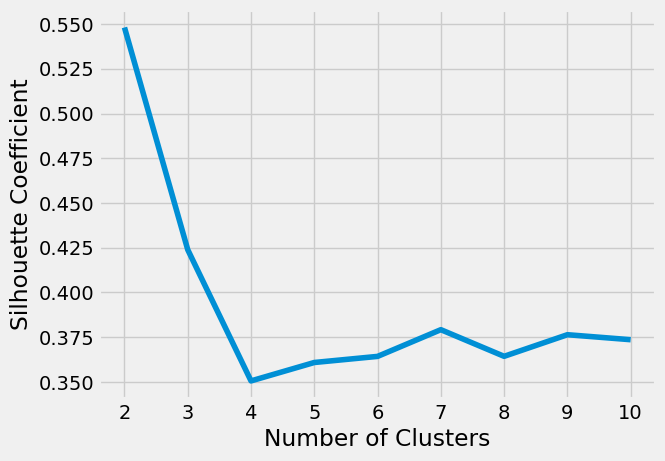

In [14]:
# 2. silhouette coefficients

from sklearn.metrics import silhouette_score

# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_coefficients.append(score)

plt.style.use("fivethirtyeight")
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

<h3 style="color:blue">Hierarchical Clustering</h3>

Text(0, 0.5, 'X1')

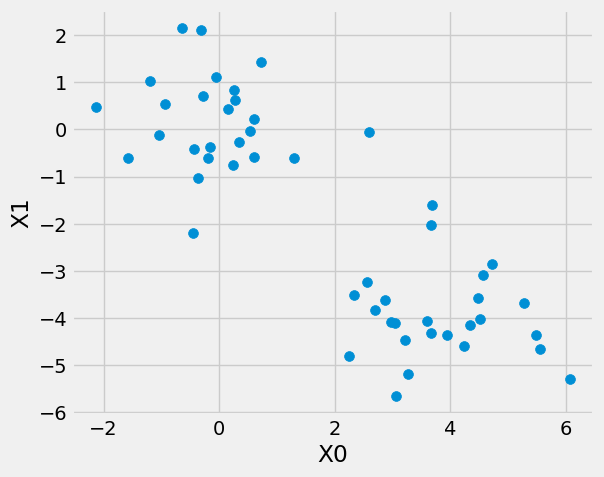

In [16]:
np.random.seed(111)
n = 50
m = int(n/2)
X_data = np.random.randn(n,2)
X_data[0:m, 0] = X_data[0:m, 0] + 4
X_data[0:m, 1] = X_data[0:m, 1] - 4

f, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_data[:,0], X_data[:,1], s=50) 
ax.set_xlabel('X0')
ax.set_ylabel('X1')

In [17]:
# The linkage() function from scipy implements several clustering functions in python. In the following example we use the data from the previous section to plot the hierarchical clustering dendrogram using complete, single, and average linkage clustering, with Euclidean distance as the dissimilarity measure. We begin by clustering observations using complete linkage:
from scipy.cluster.hierarchy import linkage
hc_complete = linkage(X_data, 'complete')
hc_average = linkage(X_data, "average")
hc_single = linkage(X_data, "single")

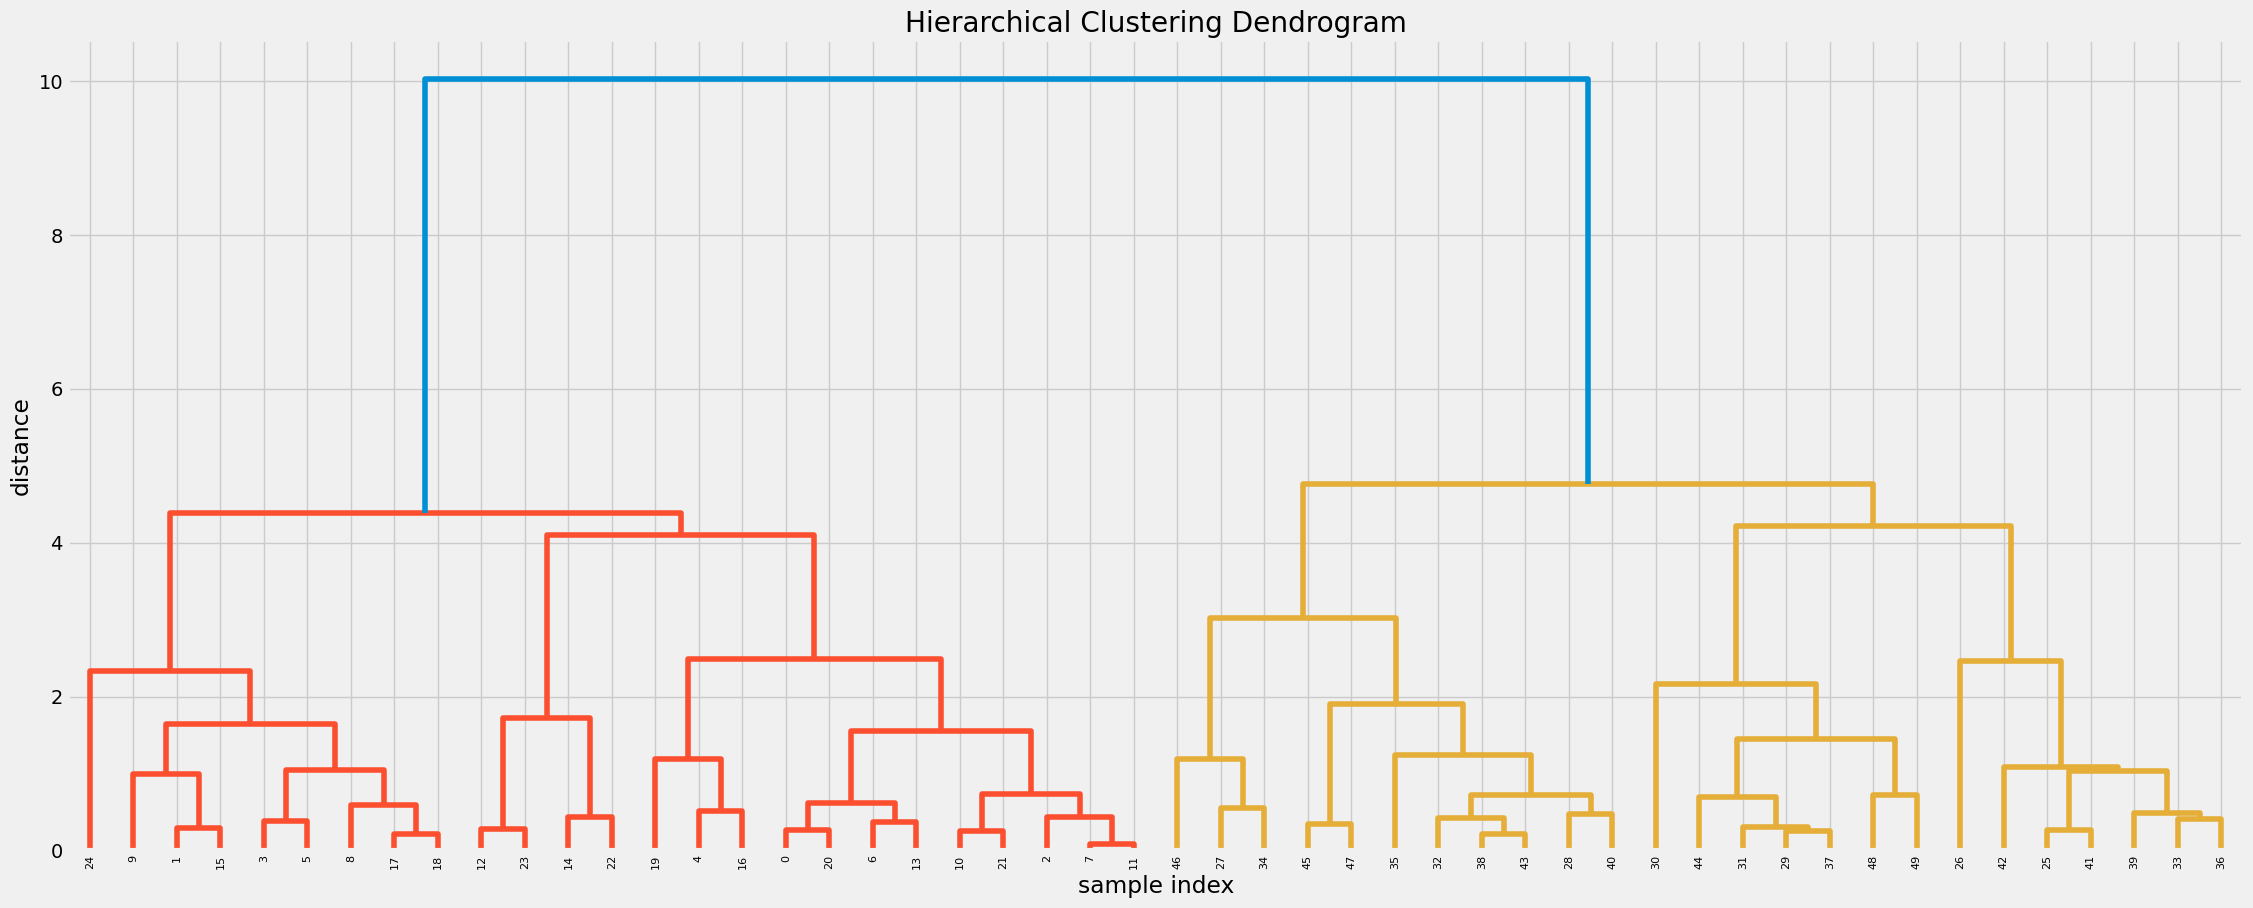

In [18]:
# We can now plot the dendrograms obtained using the usual dendrogram() function. The numbers at the bottom of the plot identify each observation:

from scipy.cluster.hierarchy import dendrogram

# calculate full dendrogram
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(
    hc_complete,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
)
plt.show()

In [19]:
# To determine the cluster labels for each observation associated with a given cut of the dendrogram, we can use the cut_tree() function:

from scipy.cluster.hierarchy import cut_tree
print(cut_tree(hc_complete, n_clusters = 2).T) # Printing transpose just for space

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1]]


<h2 style="color:orange">Frequent Pattern Mining</h2>

<h3 style="color:blue">A case study of movie recommendation</h3>

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [23]:
import requests, zipfile, io
zipfile.ZipFile(io.BytesIO(requests.get('http://files.grouplens.org/datasets/movielens/ml-latest-small.zip').content)).extractall()

In [24]:
ls -a ml-latest-small

 Volume in drive C is Windows-SSD
 Volume Serial Number is F03D-63FD

 Directory of C:\Users\George\Dropbox\nBox\NUS_ISEM\My Teachings\2025_26 Sem 1\IE5005\Lecture Materials\Lecture Slides\Lecture 08


 Directory of C:\Users\George\Dropbox\nBox\NUS_ISEM\My Teachings\2025_26 Sem 1\IE5005\Lecture Materials\Lecture Slides\Lecture 08\ml-latest-small

05/10/2025  02:49 pm    <DIR>          .
05/10/2025  02:49 pm    <DIR>          ..
05/10/2025  02:49 pm           197,979 links.csv
05/10/2025  02:49 pm           494,431 movies.csv
05/10/2025  02:49 pm         2,483,723 ratings.csv
05/10/2025  02:49 pm             8,342 README.txt
05/10/2025  02:49 pm           118,660 tags.csv
               5 File(s)      3,303,135 bytes
               2 Dir(s)  486,934,917,120 bytes free


File Not Found


Here we can see from the directory of the uncompressed file that we have a total of 5 data set, we are going to select and observed which one that contain needed data for the implementation of association rules. 

In [26]:
data_movies = pd.read_csv('ml-latest-small/movies.csv')
data_tages = pd.read_csv('ml-latest-small/tags.csv')
data_ratings = pd.read_csv('ml-latest-small/ratings.csv')

In [27]:
data_movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


This is the only dataset that contains the titile of the movies and each movie unique key.

In [29]:
data_movies.movieId.value_counts(),print('Number of duplicated unique ids are: ',data_movies.movieId.duplicated().sum())

Number of duplicated unique ids are:  0


(movieId
 1         1
 53322     1
 53129     1
 53138     1
 53140     1
          ..
 4390      1
 4392      1
 4393      1
 4394      1
 193609    1
 Name: count, Length: 9742, dtype: int64,
 None)

This dataset contain the added tags to the movie plus the userid which is valuable to be considered as an index to each transaction, on the other hand the dataset has less movie ids than the rating dataset which made us select it instead.

In [31]:
data_tages

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
...,...,...,...,...
3678,606,7382,for katie,1171234019
3679,606,7936,austere,1173392334
3680,610,3265,gun fu,1493843984
3681,610,3265,heroic bloodshed,1493843978


In [32]:
data_tages.movieId.value_counts()

movieId
296     181
2959     54
924      41
293      35
7361     34
       ... 
3307      1
3310      1
3317      1
830       1
2719      1
Name: count, Length: 1572, dtype: int64

Movies rating data contain more that 9k movies ids which can be usefull to be merged with the movies title dataset.

In [34]:
data_ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [35]:
data_ratings.movieId.value_counts()

movieId
356       329
318       317
296       307
593       279
2571      278
         ... 
86279       1
86922       1
5962        1
87660       1
163981      1
Name: count, Length: 9724, dtype: int64

in this case inner join is selected since we need the data only when both movieId labels are existed on both datasets.

more details about merging can be found in pandas documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/merging.html

In [37]:
merge = data_movies.merge(data_tages,on = 'movieId',how = 'inner')
merge

,movieId,title,genres,userId,tag,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,336,pixar,1139045764
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,474,pixar,1137206825
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,567,fun,1525286013
3,2,Jumanji (1995),Adventure|Children|Fantasy,62,fantasy,1528843929
4,2,Jumanji (1995),Adventure|Children|Fantasy,62,magic board game,1528843932
...,...,...,...,...,...,...
3678,187595,Solo: A Star Wars Story (2018),Action|Adventure|Children|Sci-Fi,62,star wars,1528934552
3679,193565,Gintama: The Movie (2010),Action|Animation|Comedy|Sci-Fi,184,anime,1537098582
3680,193565,Gintama: The Movie (2010),Action|Animation|Comedy|Sci-Fi,184,comedy,1537098587
3681,193565,Gintama: The Movie (2010),Action|Animation|Comedy|Sci-Fi,184,gintama,1537098603


In [38]:
# Dropiong unneeded columns.
merge.drop(columns=['tag','timestamp','genres'],inplace=True)
merge

,movieId,title,userId
0,1,Toy Story (1995),336
1,1,Toy Story (1995),474
2,1,Toy Story (1995),567
3,2,Jumanji (1995),62
4,2,Jumanji (1995),62
...,...,...,...
3678,187595,Solo: A Star Wars Story (2018),62
3679,193565,Gintama: The Movie (2010),184
3680,193565,Gintama: The Movie (2010),184
3681,193565,Gintama: The Movie (2010),184


Since we are going to merge. lets observe how many users we have.

In [40]:
len(merge.userId.unique()) 

58

Here we preprocess the dataset to create a transactional list were every row represent a user and his selected movies

In [42]:
merge_list = merge.groupby(by = ["userId"])["title"].apply(list).reset_index()
merge_list.head()

,userId,title
0,2,"[Step Brothers (2008), Step Brothers (2008), S..."
1,7,"[Departed, The (2006)]"
2,18,"[Carlito's Way (1993), Carlito's Way (1993), C..."
3,21,"[My Best Friend's Wedding (1997), My Best Frie..."
4,49,"[Interstellar (2014), Interstellar (2014), Int..."


In [43]:
# sample of the list
merge_list = merge_list["title"].tolist()
merge_list[0:3]

[['Step Brothers (2008)',
  'Step Brothers (2008)',
  'Step Brothers (2008)',
  'Warrior (2011)',
  'Warrior (2011)',
  'Warrior (2011)',
  'Wolf of Wall Street, The (2013)',
  'Wolf of Wall Street, The (2013)',
  'Wolf of Wall Street, The (2013)'],
 ['Departed, The (2006)'],
 ["Carlito's Way (1993)",
  "Carlito's Way (1993)",
  "Carlito's Way (1993)",
  'Godfather: Part II, The (1974)',
  'Godfather: Part II, The (1974)',
  'Pianist, The (2002)',
  'Pianist, The (2002)',
  'Lucky Number Slevin (2006)',
  'Fracture (2007)',
  'Fracture (2007)',
  'Fracture (2007)',
  'Upside Down: The Creation Records Story (2010)',
  'Upside Down: The Creation Records Story (2010)',
  'Upside Down: The Creation Records Story (2010)',
  'Just Eat It: A Food Waste Story (2014)',
  'Just Eat It: A Food Waste Story (2014)']]

Here data is transfered as a binary input to be accepted by the algorithm, serveral methods are avalible in several packages such as: one-hot encoding

In [45]:
!pip install mlxtend


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(merge_list).transform(merge_list)
df = pd.DataFrame(te_ary, columns=te.columns_)
df.head()

,(500) Days of Summer (2009),...And Justice for All (1979),10 Cloverfield Lane (2016),10 Things I Hate About You (1999),101 Dalmatians (1996),101 Dalmatians (One Hundred and One Dalmatians) (1961),"11'09""01 - September 11 (2002)",12 Angry Men (1957),127 Hours (2010),13 Going on 30 (2004),2001: A Space Odyssey (1968),21 Grams (2003),25th Hour (2002),28 Days Later (2002),"39 Steps, The (1935)",3:10 to Yuma (2007),"40-Year-Old Virgin, The (2005)","400 Blows, The (Les quatre cents coups) (1959)",42 Up (1998),84 Charing Cross Road (1987),8MM (1999),A Million Ways to Die in the West (2014),A Pigeon Sat on a Branch Reflecting on Existence (2014),A Story of Children and Film (2013),A.I. Artificial Intelligence (2001),About a Boy (2002),"Accused, The (1988)",Adam's Rib (1949),Addams Family Values (1993),"Addams Family, The (1991)","Adventures of Priscilla, Queen of the Desert, The (1994)","Adventures of Robin Hood, The (1938)","African Queen, The (1951)",After the Thin Man (1936),"Age of Innocence, The (1993)",Air Force One (1997),Airheads (1994),Airplane! (1980),Akira (1988),Aladdin (1992),Alfie (1966),Alice Adams (1935),Alice Doesn't Live Here Anymore (1974),Alice in Wonderland (1951),Alien (1979),Aliens (1986),Alive (1993),All About Eve (1950),All the King's Men (1949),All the President's Men (1976),All the Real Girls (2003),Almost Famous (2000),Amadeus (1984),"Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)",Amen. (2002),America's Sweethearts (2001),American Gangster (2007),American History X (1998),American Movie (1999),American Pie (1999),"American President, The (1995)",American Splendor (2003),"American in Paris, An (1951)","Americanization of Emily, The (1964)",Anastasia (1956),Anatomy of a Murder (1959),Anchorman 2: The Legend Continues (2013),Anchorman: The Legend of Ron Burgundy (2004),And Then There Were None (1945),And the Band Played On (1993),"Andalusian Dog, An (Chien andalou, Un) (1929)",Angel's Egg (Tenshi no tamago) (1985),Angie (1994),Animal House (1978),"Animatrix, The (2003)",Anna Karenina (1997),Anne Frank Remembered (1995),Anne of the Thousand Days (1969),Annie Hall (1977),Another Thin Man (1939),"Apartment, The (1960)",Apocalypse Now (1979),Apollo 13 (1995),Arachnophobia (1990),Argo (2012),"Aristocats, The (1970)",Armageddon (1998),Around the World in 80 Days (1956),Arrival (2016),"Arrival, The (1996)",Arsenic and Old Lace (1944),"Astronaut's Wife, The (1999)",Au Hasard Balthazar (1966),Auntie Mame (1958),Avalon (1990),Avatar (2009),"Avengers, The (2012)",Avengers: Infinity War - Part I (2018),"Aviator, The (2004)","Awful Truth, The (1937)","Babadook, The (2014)",Babe (1995),Babel (2006),Babette's Feast (Babettes gæstebud) (1987),Babylon 5: In the Beginning (1998),"Bachelor and the Bobby-Soxer, The (1947)",Back to the Future (1985),Back to the Future Part II (1989),Bad Day at Black Rock (1955),"Bad News Bears, The (1976)","Bad Seed, The (1956)","Bad and the Beautiful, The (1952)","Ballad of Jack and Rose, The (2005)","Bank Job, The (2008)",Barton Fink (1991),"Basketball Diaries, The (1995)",Batman (1989),Batman Forever (1995),Batman Returns (1992),Batman v Superman: Dawn of Justice (2016),Battle Royale (Batoru rowaiaru) (2000),"Battle of Algiers, The (La battaglia di Algeri) (1966)",Beasts of No Nation (2015),Beasts of the Southern Wild (2012),Beat the Devil (1953),"Beautiful Mind, A (2001)",Beauty and the Beast (1991),Before Sunrise (1995),Before Sunset (2004),Begotten (1990),Being Julia (2004),Being There (1979),"Believer, The (2001)",Bend It Like Beckham (2002),Benny & Joon (1993),Best in Show (2000),Better Luck Tomorrow (2002),Better Off Dead... (1985),Beyond Silence (Jenseits der Stille) (1996),Big (1988),Big Business (1988),Big Daddy (1999),Big Eyes (2014),Big Fish (2003),Big Hero 6 (2014),"Big Kahuna, The (2000)","Big Lebowski, The (1998)",Big Night (1996),"Big Short, The (2015)","Big Sleep, The (1946)",Big Top Pee-Wee (1988),Bill & Ted's Bogus Journey (1991),Bill & Ted's Excellent Adventure (1989

GENERATING FREQUENT ITEMSETS

This section implement the use of the itemsets generation according to the selected parameters min_support=0.01,max_len=2 as a threshold to paneltize the algorithm of using a huge memory size of the machine (1% support value, and maxixmum length of two items in each row is selected) as well.

NOTE: Note that the results frequent items are python frozensets, which can not be selected by pandas methods such as pd.loc[].

<h3 style="color:blue">Apriori</h3>

In [49]:
from mlxtend.frequent_patterns import apriori
%time
apriori_frequent_itemsets = apriori(df, min_support=0.01,use_colnames=True,max_len=2)

CPU times: total: 0 ns
Wall time: 0 ns


In [50]:
apriori_frequent_itemsets['itemsets'].apply(lambda x: len(x)).value_counts()

itemsets
2    774986
1      1572
Name: count, dtype: int64

<h3 style="color:blue">FP Growth</h3>

In [52]:
from mlxtend.frequent_patterns import fpgrowth
%time
fpgrowth_frequent_itemsets = fpgrowth(df, min_support=0.01, use_colnames=True,max_len=2)
fpgrowth_frequent_itemsets.head()

CPU times: total: 0 ns
Wall time: 0 ns


,support,itemsets
0,0.051724,(Step Brothers (2008))
1,0.034483,"(Wolf of Wall Street, The (2013))"
2,0.017241,(Warrior (2011))
3,0.051724,"(Departed, The (2006))"
4,0.034483,"(Godfather: Part II, The (1974))"


In [53]:
fpgrowth_frequent_itemsets['itemsets'].apply(lambda x: len(x)).value_counts()

itemsets
2    774986
1      1572
Name: count, dtype: int64

<h3 style="color:blue">Result Analysis</h3>

Lets create new feature that can be used for furthur analysis.

In [56]:
fpgrowth_frequent_itemsets['length'] = fpgrowth_frequent_itemsets['itemsets'].apply(lambda x: len(x))
fpgrowth_frequent_itemsets

,support,itemsets,length
0,0.051724,(Step Brothers (2008)),1
1,0.034483,"(Wolf of Wall Street, The (2013))",1
2,0.017241,(Warrior (2011)),1
3,0.051724,"(Departed, The (2006))",1
4,0.034483,"(Godfather: Part II, The (1974))",1
...,...,...,...
776553,0.017241,"(Shine (1996), Night of the Shooting Stars (No...",2
776554,0.017241,"(Staying Alive (1983), Night of the Shooting S...",2
776555,0.017241,"(Gladiator (2000), Night of the Shooting Stars...",2
776556,0.017241,"(I'm Not Scared (Io non ho paura) (2003), Nigh...",2


In [57]:
# Apply some basic analysis that can used to generate some intresting insights. for example, filter by columns based on numerial conditions
fpgrowth_frequent_itemsets[(fpgrowth_frequent_itemsets['length'] > 1)
                          & (fpgrowth_frequent_itemsets['support'] > 0.06)].head()

,support,itemsets,length
5225,0.068966,"(Memento (2000), Eternal Sunshine of the Spotl...",2
5392,0.086207,"(Eternal Sunshine of the Spotless Mind (2004),...",2
5394,0.068966,"(Memento (2000), Donnie Darko (2001))",2
7011,0.068966,"(Donnie Darko (2001), Blade Runner (1982))",2
7012,0.068966,"(Memento (2000), Blade Runner (1982))",2


In [58]:
# Filtering by itemset length
fpgrowth_frequent_itemsets[(fpgrowth_frequent_itemsets['length'] != 1)]

,support,itemsets,length
1572,0.034483,"(Step Brothers (2008), Anchorman: The Legend o...",2
1573,0.017241,"(Step Brothers (2008), Corpse Bride (2005))",2
1574,0.017241,"(Step Brothers (2008), City of God (Cidade de ...",2
1575,0.017241,"(Step Brothers (2008), Departed, The (2006))",2
1576,0.017241,"(Step Brothers (2008), Terminator 2: Judgment ...",2
...,...,...,...
776553,0.017241,"(Shine (1996), Night of the Shooting Stars (No...",2
776554,0.017241,"(Staying Alive (1983), Night of the Shooting S...",2
776555,0.017241,"(Gladiator (2000), Night of the Shooting Stars...",2
776556,0.017241,"(I'm Not Scared (Io non ho paura) (2003), Nigh...",2


In [59]:
# filtering values based on thier combinations and occurances in all dataset.
fpgrowth_frequent_itemsets[fpgrowth_frequent_itemsets['itemsets'] == {'Step Brothers (2008)', 'Corpse Bride (2005)'}]

,support,itemsets,length
1573,0.017241,"(Step Brothers (2008), Corpse Bride (2005))",2


In [60]:
# we can search also by all itemset in all frequent itemsets
fpgrowth_frequent_itemsets[fpgrowth_frequent_itemsets['itemsets'].apply(lambda x: 'Step Brothers (2008)' in str(x))]

,support,itemsets,length
0,0.051724,(Step Brothers (2008)),1
1572,0.034483,"(Step Brothers (2008), Anchorman: The Legend o...",2
1573,0.017241,"(Step Brothers (2008), Corpse Bride (2005))",2
1574,0.017241,"(Step Brothers (2008), City of God (Cidade de ...",2
1575,0.017241,"(Step Brothers (2008), Departed, The (2006))",2
...,...,...,...
10131,0.017241,"(Step Brothers (2008), Prisoners (2013))",2
10201,0.017241,"(Step Brothers (2008), Old School (2003))",2
10272,0.017241,"(Step Brothers (2008), Now You See Me (2013))",2
10344,0.017241,"(Step Brothers (2008), Night at the Roxbury, A...",2


In [61]:
type(fpgrowth_frequent_itemsets['itemsets'][2])

frozenset

We can observe more the relation between support and length using correlation and hexbin plot. we can see an increse of rows that consist in more than one itemset. we can observe more insights if we had a multiple items in terms of items length instead of two only as a maximum in this example.

In [63]:
# import seaborn as sns
# sns.heatmap(data=fpgrowth_frequent_itemsets.corr(method='spearman'),
#            annot=True,
#            vmin=-1,
#            vmax=1,
#            center=0,
#            cmap='YlGnBu');

In [64]:
# fpgrowth_frequent_itemsets.plot.hexbin(x='length',y='support',cmap='viridis',gridsize=20,sharex=False,bins=10);

<h3 style="color:blue">Association Rules</h3>

In [66]:
%%time
from mlxtend.frequent_patterns import association_rules
rules = association_rules(fpgrowth_frequent_itemsets,metric="lift",min_threshold=0.01)

CPU times: total: 11.1 s
Wall time: 11.3 s


In [67]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(Step Brothers (2008)),(Anchorman: The Legend of Ron Burgundy (2004)),0.051724,0.068966,0.034483,0.666667,9.666667,0.030916,2.793103,0.945455
1,(Anchorman: The Legend of Ron Burgundy (2004)),(Step Brothers (2008)),0.068966,0.051724,0.034483,0.500000,9.666667,0.030916,1.896552,0.962963
2,(Step Brothers (2008)),(Corpse Bride (2005)),0.051724,0.051724,0.017241,0.333333,6.444444,0.014566,1.422414,0.890909
3,(Corpse Bride (2005)),(Step Brothers (2008)),0.051724,0.051724,0.017241,0.333333,6.444444,0.014566,1.422414,0.890909
4,(Step Brothers (2008)),(City of God (Cidade de Deus) (2002)),0.051724,0.051724,0.017241,0.333333,6.444444,0.014566,1.422414,0.890909
...,...,...,...,...,...,...,...,...,...,...
1549967,(Night of the Shooting Stars (Notte di San Lor...,(Gladiator (2000)),0.017241,0.034483,0.017241,1.000000,29.000000,0.016647,inf,0.982456
1549968,(I'm Not Scared (Io non ho paura) (2003)),(Night of the Shooting Stars (Notte di San Lor...,0.034483,0.017241,0.017241,0.500000,29.000000,0.016647,1.965517,1.000000
1549969,(Night of the Shooting Stars (Notte di San Lor...,(I'm Not Scared (Io non ho paura) (2003)),0.017241,0.034483,0.017241,1.000000,29.000000,0.016647,inf,0.982456
1549970,(John Wick: Chapter Two (2017)),(Hard-Boiled (Lat sau san taam) (1992)),0.034483,0.017241,0.017241,0.500000,29.000000,0.016647,1.965517,1.000000


In [68]:
rules[rules["antecedents"].apply(lambda x: "Inception (2010)" in str(x))].sort_values(ascending=False,by='lift')

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
1534852,(Inception (2010)),(Gentlemen Broncos (2009)),0.068966,0.017241,0.017241,0.25,14.500000,0.016052,1.310345,1.000000
1538020,(Inception (2010)),(Rare Exports: A Christmas Tale (Rare Exports)...,0.068966,0.017241,0.017241,0.25,14.500000,0.016052,1.310345,1.000000
1538286,(Inception (2010)),((500) Days of Summer (2009)),0.068966,0.017241,0.017241,0.25,14.500000,0.016052,1.310345,1.000000
1538320,(Inception (2010)),"(Avengers, The (2012))",0.068966,0.034483,0.034483,0.50,14.500000,0.032105,1.931034,1.000000
1538360,(Inception (2010)),(Captain Phillips (2013)),0.068966,0.034483,0.034483,0.50,14.500000,0.032105,1.931034,1.000000
...,...,...,...,...,...,...,...,...,...,...
36,(Inception (2010)),(Step Brothers (2008)),0.068966,0.051724,0.017241,0.25,4.833333,0.013674,1.264368,0.851852
6182,(Inception (2010)),(Pulp Fiction (1994)),0.068966,0.068966,0.017241,0.25,3.625000,0.012485,1.241379,0.777778
10874,(Inception (2010)),(Fight Club (1999)),0.068966,0.068966,0.017241,0.25,3.625000,0.012485,1.241379,0.777778
460,(Inception (2010)),(Anchorman: The Legend of Ron Burgundy (2004)),0.068966,0.068966,0.017241,0.25,3.625000,0.012485,1.241379,0.777778


A less messy way to group the top 10 related movies to the selected one.

We can see here the selected movie inception has top values of lift on related movie due to the same director in them (Dunkirk)

In [70]:
rules[rules["antecedents"].apply(lambda x: "Inception (2010)" in str(x))].groupby(
    ['antecedents', 'consequents'])[['lift']].max().sort_values(ascending=False,by='lift').head(10)

lift
antecedents        consequents                                             
(Inception (2010)) (Gentlemen Broncos (2009))                          14.5
                   (Life Aquatic with Steve Zissou, The (2004))        14.5
                   (400 Blows, The (Les quatre cents coups) (1959))    14.5
                   (A Pigeon Sat on a Branch Reflecting on Existen...  14.5
                   (Arrival (2016))                                    14.5
                   (Andalusian Dog, An (Chien andalou, Un) (1929))     14.5
                   (Angel's Egg (Tenshi no tamago) (1985))             14.5
                   (Illusionist, The (2006))                           14.5
                   (Dunkirk (2017))                                    14.5
                   (Don't Breathe (2016))                              14.5

An increasing value of lift is relatively associated with the increase of other measures such as confidence, lets observe top 10 movies that are relativley confidenent to be watched with the selected movie 'Inception'.

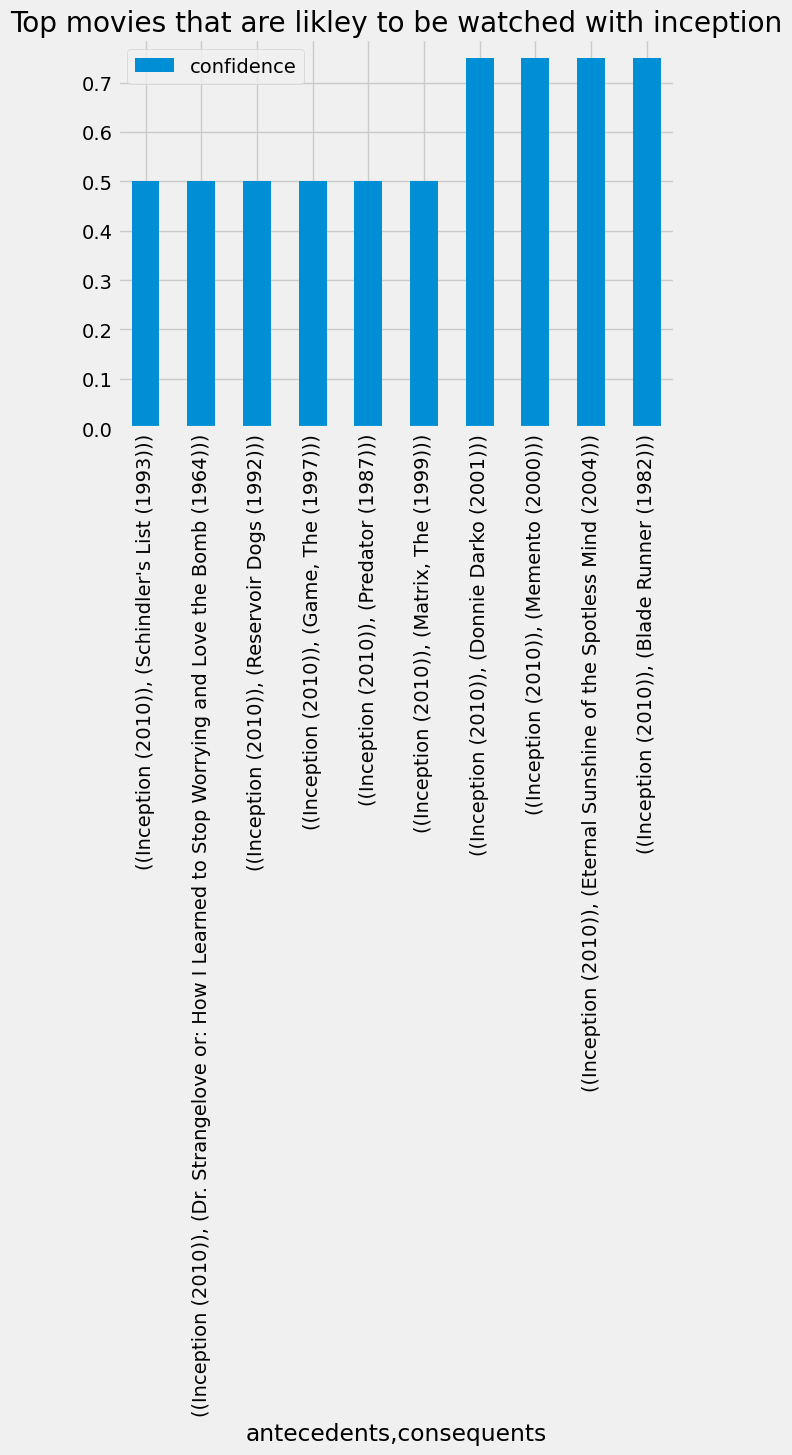

In [72]:
rules[rules["antecedents"].apply(lambda x: "Inception (2010)" in str(x))].groupby(
    ['antecedents', 'consequents'])[['confidence']].max().sort_values(ascending=False,
                                                                      by='confidence').head(10).plot(kind='bar').invert_xaxis()
plt.title('Top movies that are likley to be watched with inception');

<h3 style="color:blue">Visualizing Association Rules</h3>

One intresting way to view such data can be used by a network analysis type of plots which can be used to visulize the relation between each feature and it is crosspounding feature in same dataset. Here we used Networkx modules which can be implemented to selected top 100 strongest relation. netwrokx modules has many layouts can be plot which depends on nodes, here we selected 'planar_layout' as it can present the huge selection of data points clearly and beatifully.

In [75]:
rules['antecedents'] = rules.antecedents.apply(lambda x: next(iter(x)))
rules['consequents'] = rules.consequents.apply(lambda x: next(iter(x)))

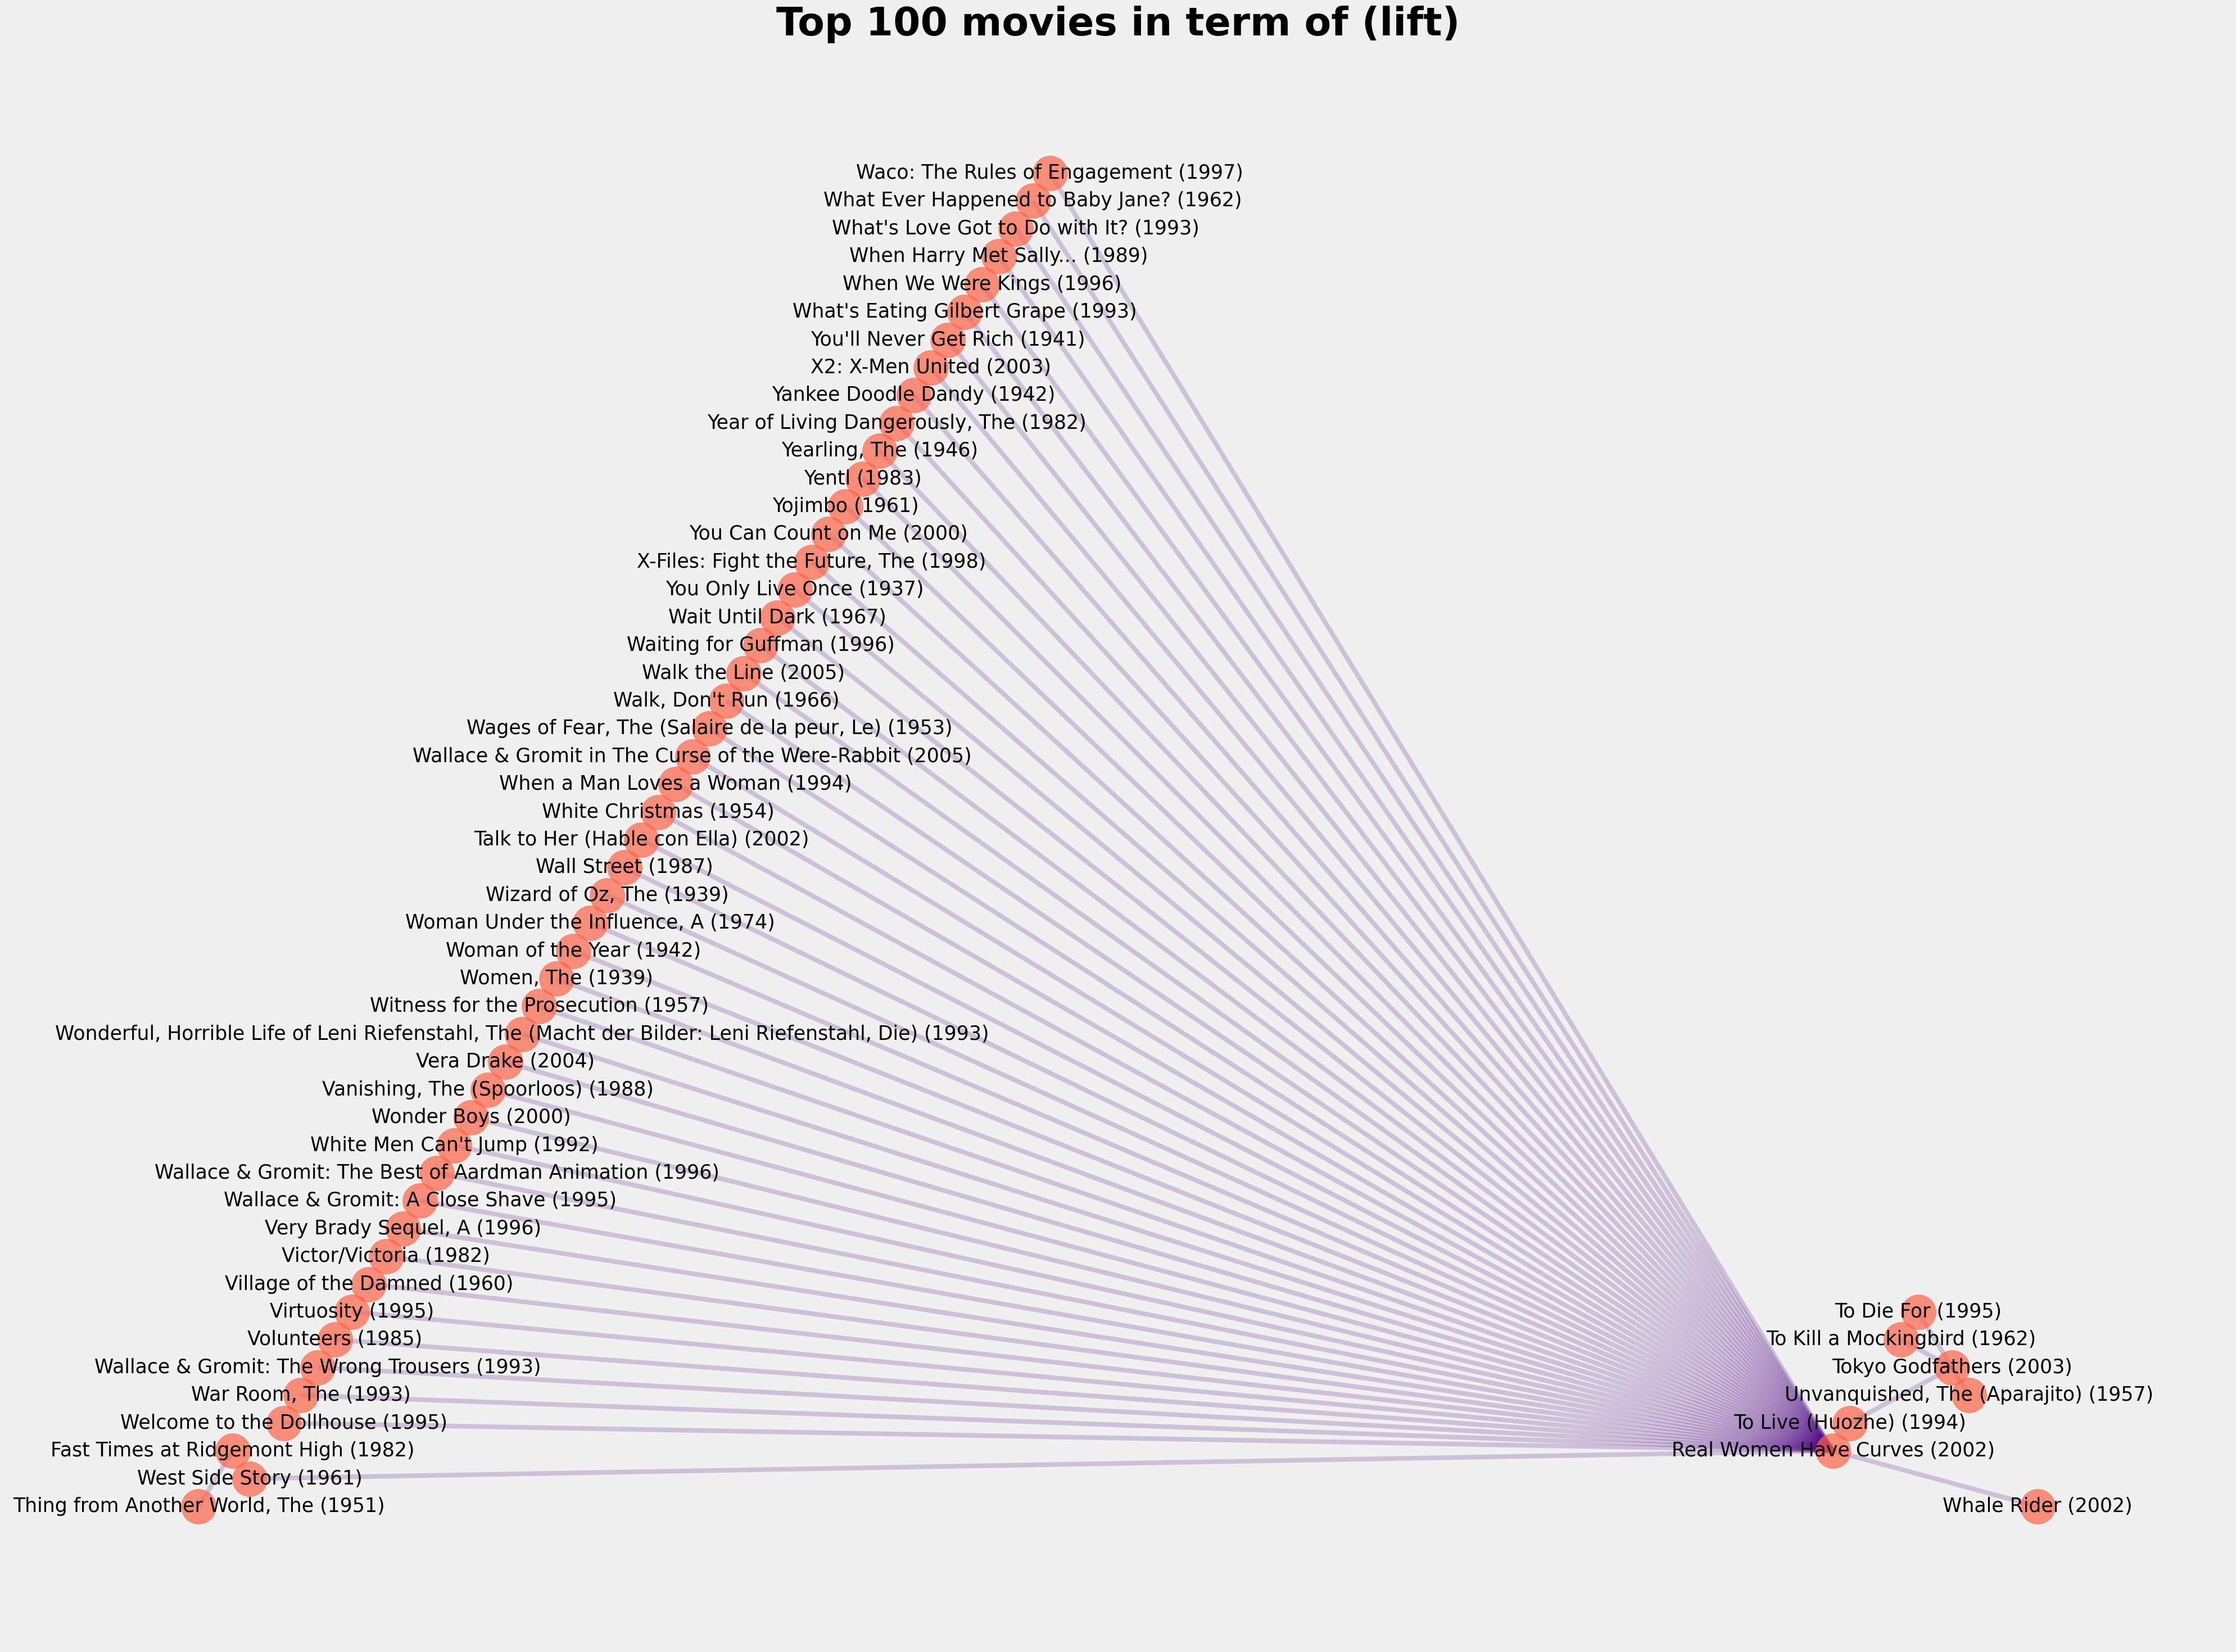

In [76]:
import networkx as nx
import warnings
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
edges = nx.from_pandas_edgelist(rules.sort_values(ascending=False,by='lift').head(100)
                           ,source='antecedents',target='consequents',edge_attr=None)
plt.subplots(figsize=(40,30))
plt.suptitle('Top 100 movies in term of (lift)', fontsize = 50,fontweight = 'bold')
pos = nx.planar_layout(edges)
nx.draw_networkx_nodes(edges, pos, node_size = 2000,alpha= 0.7,node_color = 'tomato')
nx.draw_networkx_edges(edges, pos, width = 6, alpha = 0.2, edge_color = 'indigo')
nx.draw_networkx_labels(edges, pos, font_size = 25)
plt.grid()
plt.axis('off')
plt.tight_layout()
plt.show()